In [88]:
import numpy as np
import torch

In [89]:
# 5행 4열 습도, 강수량, 최고온도, 최저온도
input_=np.array([[63,56,34,2],
                 [96,78,39,1],
                 [52,106,33,2],
                 [77,56,36,5],
                 [114,98,35,7]], dtype='float32')
input_.dtype

dtype('float32')

In [90]:
# 5행 2열          옥수수 감자 수확량 개수
label_=np.array([[56,80],
                 [91,80],
                 [120,144],
                 [34,65],
                 [100,135]], dtype='float32')
label_.dtype

dtype('float32')

In [91]:
# input, label 다 tensor로 변환(딥러닝 모델 입력으로 쓰려고) - autograd, backword
input_=torch.from_numpy(input_)
label_=torch.from_numpy(label_)
print(input_.shape, label_.shape)

torch.Size([5, 4]) torch.Size([5, 2])


In [92]:
from torch import nn
from torch import optim
torch.manual_seed(1)

In [93]:
# 입력 4개 - 출력 2개인 선형모델
model=nn.Linear(in_features=4, out_features=2)
# 정답과 예측값의 차이(작을수록(0에 가까울수록) 예측이 정확함)
loss=nn.MSELoss()

optimizer=optim.SGD(model.parameters(), lr=1e-4) #lr=0.000
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [97]:
# 선형모델 학습하는 코드
# 100번 학습시킬거임 -> weight, bios 점진적으로 최적화하려고
# zip : 입력(x) 정답(y) 을 하나의 쌍으로 묶어서 순서대로 던져준다
for epoch in range(100):
    for x,y in zip(input_, label_):
        yhat=model(x) # nn.linear에 있는 model.__call__ => forward (선형모델 계산) 입력 - 은닉 - 출력
        loss1=loss(yhat,y) # __call__ => forward
        loss1.backward() # 역전파(w, b에 대한 gradient 계산)
        optimizer.step() # SGD 사용해서 w,b 업데이트
        optimizer.zero_grad() # gradient 초기화
    print(loss1)

tensor(44.7192, grad_fn=<MseLossBackward0>)
tensor(44.6818, grad_fn=<MseLossBackward0>)
tensor(44.6451, grad_fn=<MseLossBackward0>)
tensor(44.6097, grad_fn=<MseLossBackward0>)
tensor(44.5753, grad_fn=<MseLossBackward0>)
tensor(44.5415, grad_fn=<MseLossBackward0>)
tensor(44.5087, grad_fn=<MseLossBackward0>)
tensor(44.4769, grad_fn=<MseLossBackward0>)
tensor(44.4456, grad_fn=<MseLossBackward0>)
tensor(44.4152, grad_fn=<MseLossBackward0>)
tensor(44.3857, grad_fn=<MseLossBackward0>)
tensor(44.3564, grad_fn=<MseLossBackward0>)
tensor(44.3282, grad_fn=<MseLossBackward0>)
tensor(44.3004, grad_fn=<MseLossBackward0>)
tensor(44.2730, grad_fn=<MseLossBackward0>)
tensor(44.2463, grad_fn=<MseLossBackward0>)
tensor(44.2200, grad_fn=<MseLossBackward0>)
tensor(44.1944, grad_fn=<MseLossBackward0>)
tensor(44.1691, grad_fn=<MseLossBackward0>)
tensor(44.1443, grad_fn=<MseLossBackward0>)
tensor(44.1199, grad_fn=<MseLossBackward0>)
tensor(44.0958, grad_fn=<MseLossBackward0>)
tensor(44.0721, grad_fn=<MseLoss

In [95]:
pred=model(input_)
loss1=loss(pred, label_)
loss1

tensor(381.5443, grad_fn=<MseLossBackward0>)

In [96]:
# 미분 기록 버리고 숫자데이터만 남김 -> 넘파이 배열로 되돌림
label_.detach().numpy()

array([[ 56.,  80.],
       [ 91.,  80.],
       [120., 144.],
       [ 34.,  65.],
       [100., 135.]], dtype=float32)

In [99]:
pred.detach().numpy()

array([[ 37.057903,  81.12234 ],
       [ 67.05585 , 107.05826 ],
       [101.51078 , 181.4571  ],
       [ 37.21413 ,  79.911705],
       [103.52025 , 147.64677 ]], dtype=float32)

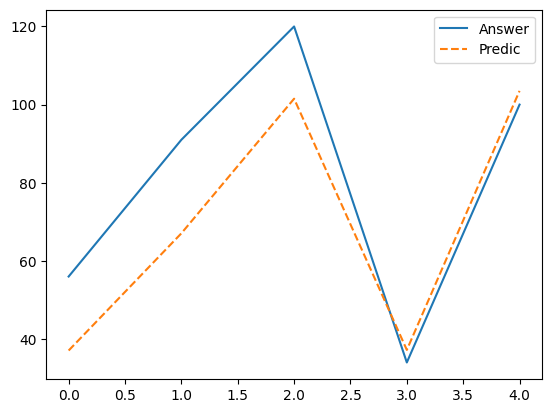

In [102]:
import matplotlib.pyplot as plt
plt.plot(label_[:,0].detach().numpy(), label="Answer")
plt.plot(pred[:,0].detach().numpy(),"--", label="Predic")
plt.legend()
plt.show()

In [103]:
###########################################

In [106]:
loss1=nn.MSELoss()
yhat=torch.tensor([3.0], requires_grad=True)
y=torch.tensor([1.0])
print(loss1(yhat, y))
print(loss1.__call__(yhat, y))
print(loss1.forward(yhat, y))

tensor(4., grad_fn=<MseLossBackward0>)
tensor(4., grad_fn=<MseLossBackward0>)
tensor(4., grad_fn=<MseLossBackward0>)


In [ ]:
torch.save(model.state_dict(), 'model.pt')